ПРЕДИКТИВНАЯ МОДЕЛЬ РАСПРЕДЕЛЕНИЯ ТОВАРОВ НА 2026 ГОД
ШВЕЙНОЕ ПРОИЗВОДСТВО - ОПТИМИЗАЦИЯ SUPPLY CHAIN

📂 Загрузка данных...
✅ Данные загружены и очищены от возвратов

3. ПРОГНОЗИРОВАНИЕ СПРОСА НА 2026 ГОД
Размер обучающей выборки: 1071 записей
Размер тестовой выборки: 441 записей
✅ Модель обучена (R² test: 0.768)

📈 Генерация прогноза на 2026...
✅ Прогноз сгенерирован: 756 записей
   Общий прогноз на 2026: 30,278 шт.

3.5. ДЕТАЛИЗАЦИЯ ПРОГНОЗА ДО АРТИКУЛОВ
✅ Уникальных комбинаций (тип+город+артикул): 20142
✅ Прогноз детализирован до артикулов: 241704 записей
✅ Прогноз по артикулам сохранён: article_forecast_2026.csv

📊 ПРИМЕР ПРОГНОЗА ПО АРТИКУЛАМ (топ-5 по продажам):
   • Артикул 1338 (Blouse, Green, р.46): 1 шт. в Нижний Новгород за 2026-06
   • Артикул 3353 (Dress, Brown, р.46): 1 шт. в Нижний Новгород за 2026-02
   • Артикул 3353 (Dress, Brown, р.46): 1 шт. в Нижний Новгород за 2026-01
   • Артикул 2513 (Jeans, Black, р.48): 1 шт. в Екатеринбург за 2026-02
   • Артикул 123 (Jacket,

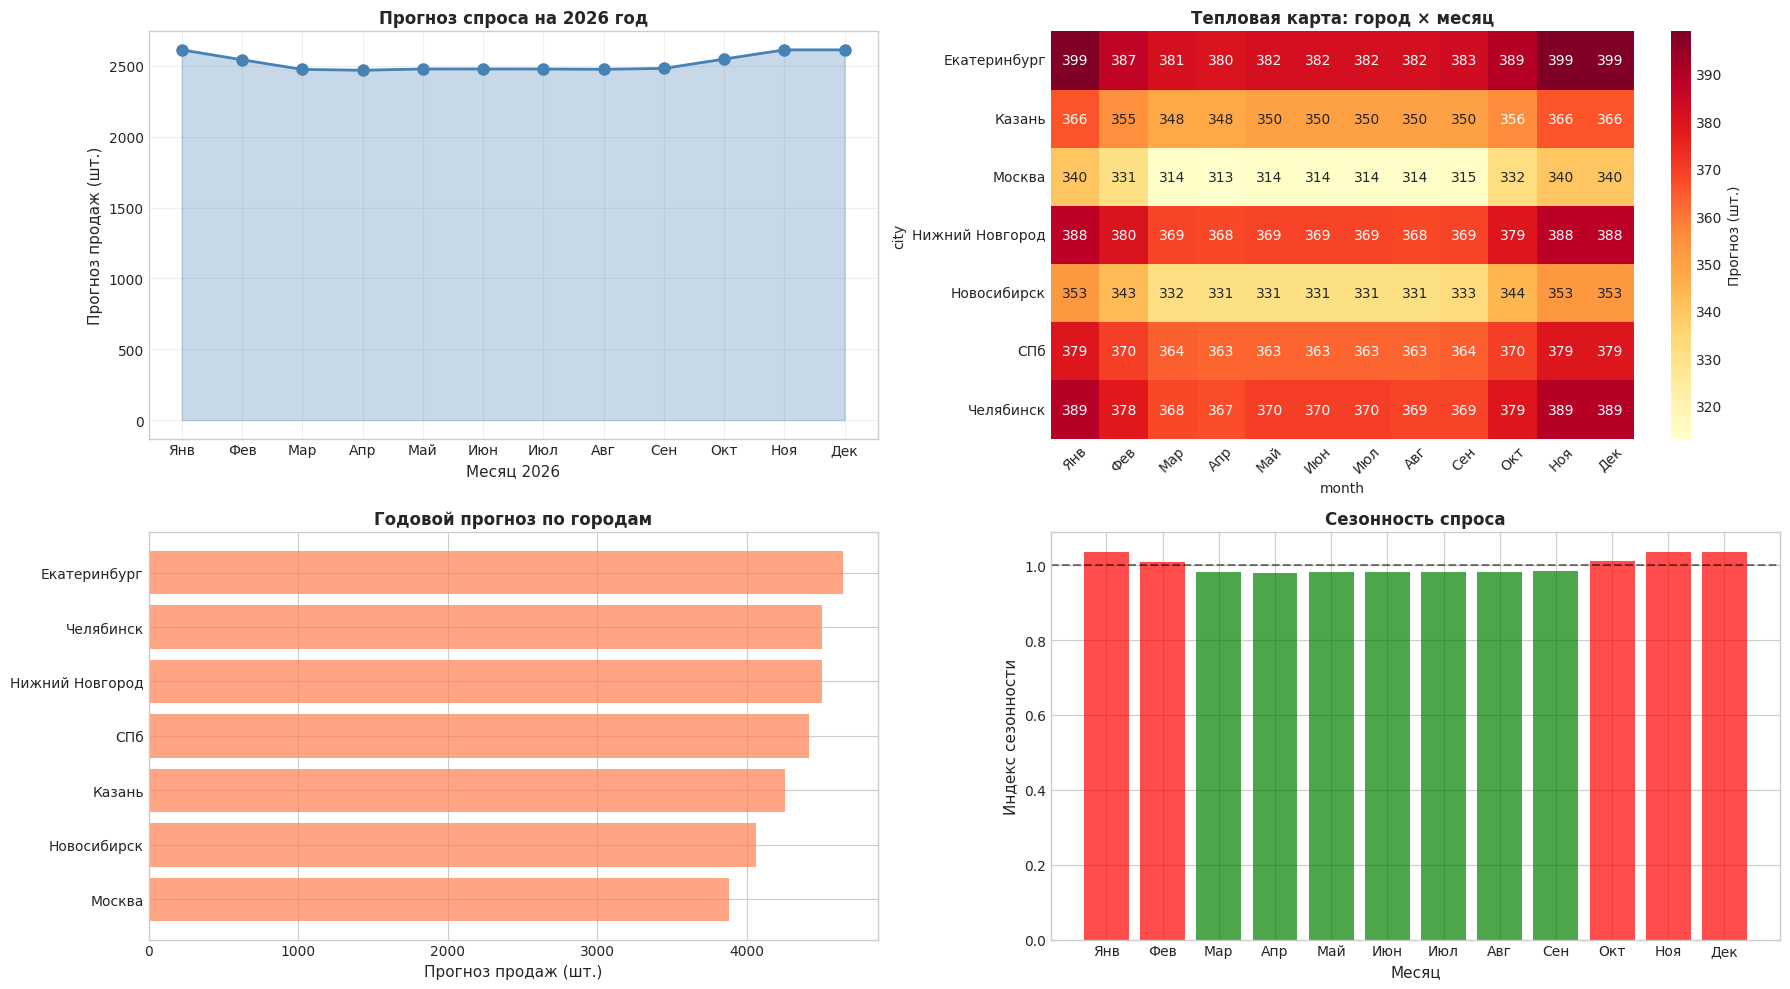


4. ПЛАН РАСПРЕДЕЛЕНИЯ НА 2026 ГОД

📅 Помесячный план остатков (годовой запас с сезонной корректировкой):

   Месяц 1 (Янв):
   • Москва         :    3,654 шт. (загрузка:  0.73%)
   • СПб            :    4,043 шт. (загрузка:  1.35%)
   • Новосибирск    :    3,784 шт. (загрузка:  1.51%)
   • Казань         :    3,914 шт. (загрузка:  1.96%)
   • Екатеринбург   :    4,243 шт. (загрузка:  2.12%)
   • Ростов-на-Дону :      261 шт. (загрузка:  0.10%)

   Месяц 2 (Фев):
   • Москва         :    3,557 шт. (загрузка:  0.71%)
   • СПб            :    3,947 шт. (загрузка:  1.32%)
   • Новосибирск    :    3,677 шт. (загрузка:  1.47%)
   • Казань         :    3,797 шт. (загрузка:  1.90%)
   • Екатеринбург   :    4,116 шт. (загрузка:  2.06%)
   • Ростов-на-Дону :      254 шт. (загрузка:  0.10%)

   Месяц 3 (Мар):
   • Москва         :    4,285 шт. (загрузка:  0.86%)
   • СПб            :    4,928 шт. (загрузка:  1.64%)
   • Новосибирск    :    4,517 шт. (загрузка:  1.81%)
   • Казань         :    4,

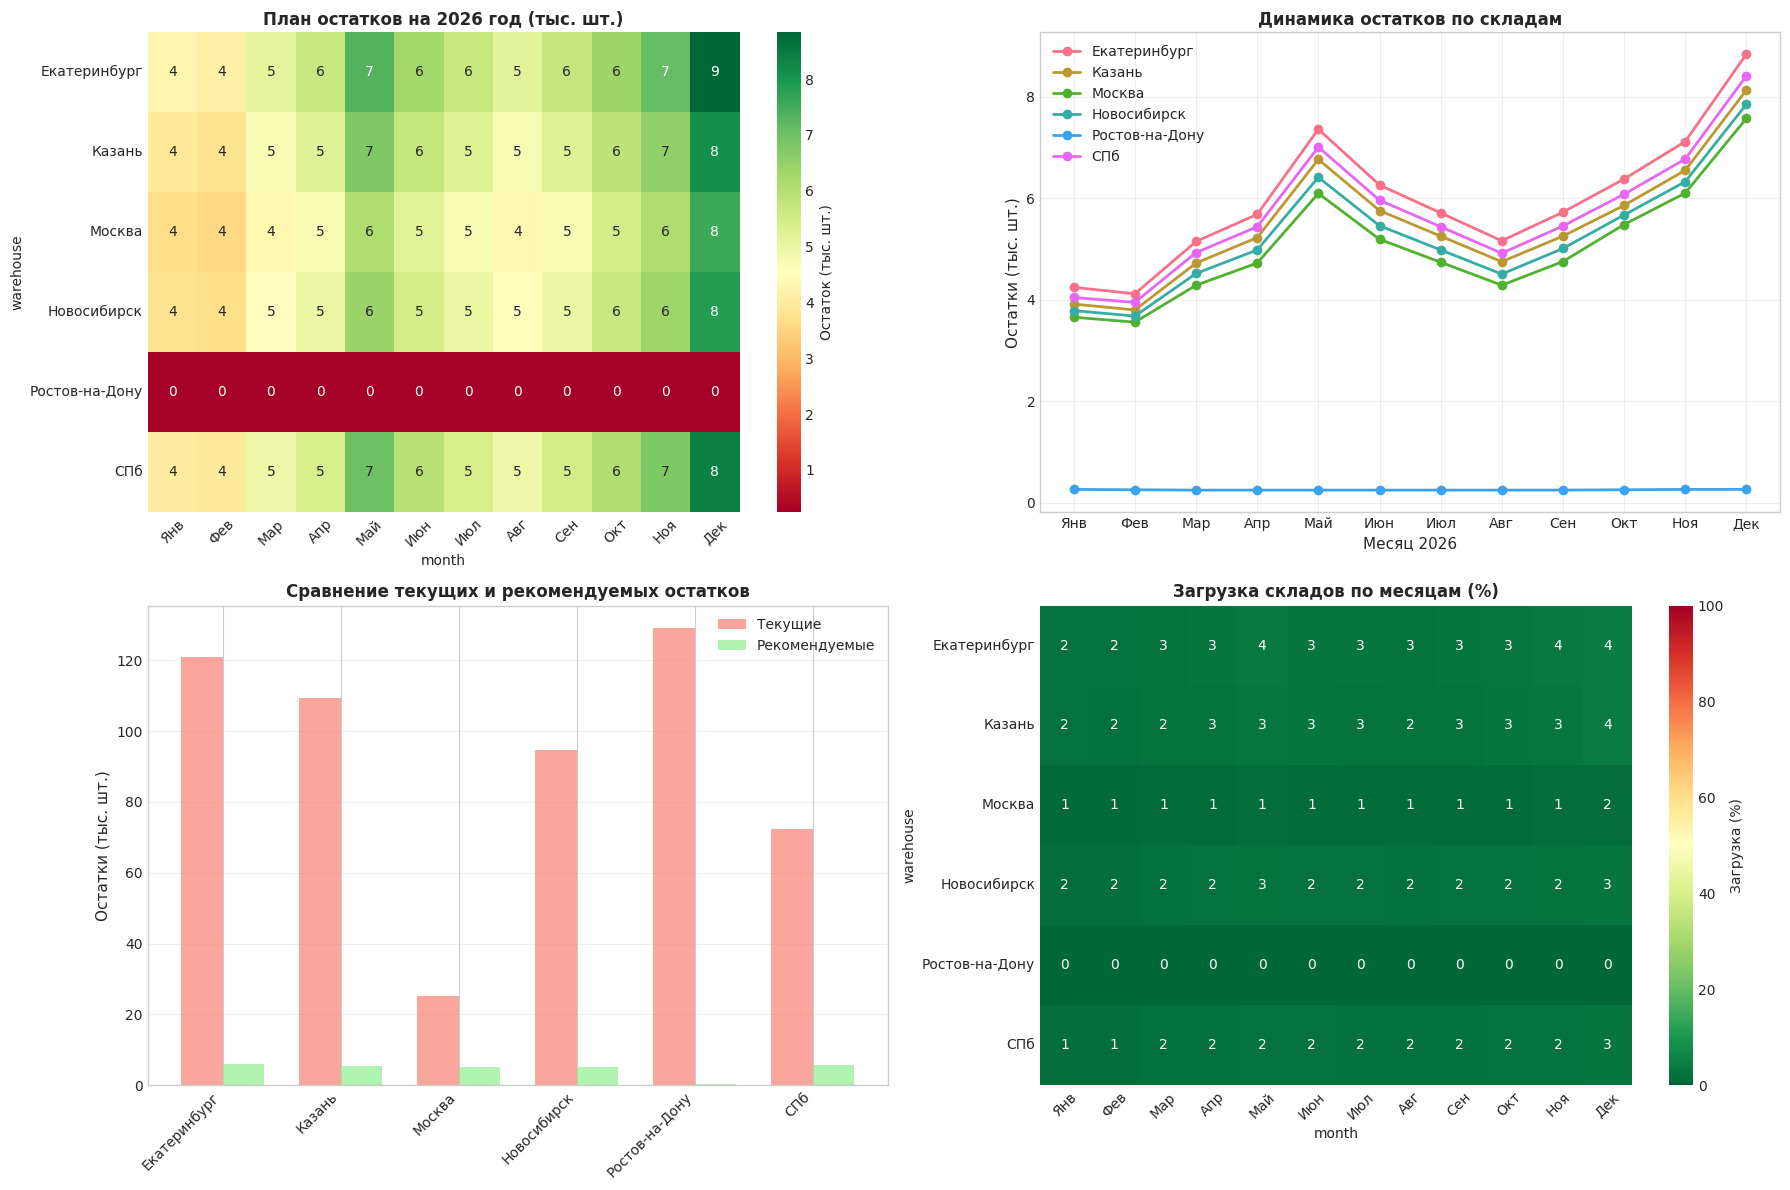


6. СОХРАНЕНИЕ ПЛАНА
✅ Прогноз по артикулам (агрегированный по России) сохранён: article_forecast_2026_aggregated.csv
✅ План сохранен в 'supply_plan_2026.csv'
✅ Квартальный план сохранен в 'quarterly_supply_plan_2026.csv'

📊 КВАРТАЛЬНЫЙ ПЛАН:

   Квартал 1:
   • Москва         :    3,832 шт.
   • СПб            :    4,306 шт.
   • Новосибирск    :    3,993 шт.
   • Казань         :    4,144 шт.
   • Екатеринбург   :    4,502 шт.
   • Ростов-на-Дону :      254 шт.

   Квартал 2:
   • Москва         :    5,335 шт.
   • СПб            :    6,135 шт.
   • Новосибирск    :    5,616 шт.
   • Казань         :    5,914 шт.
   • Екатеринбург   :    6,434 шт.
   • Ростов-на-Дону :      247 шт.

   Квартал 3:
   • Москва         :    4,592 шт.
   • СПб            :    5,269 шт.
   • Новосибирск    :    4,832 шт.
   • Казань         :    5,084 шт.
   • Екатеринбург   :    5,532 шт.
   • Ростов-на-Дону :      247 шт.

   Квартал 4:
   • Москва         :    6,384 шт.
   • СПб            :    7,086 ш

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'

print("=" * 80)
print("ПРЕДИКТИВНАЯ МОДЕЛЬ РАСПРЕДЕЛЕНИЯ ТОВАРОВ НА 2026 ГОД")
print("ШВЕЙНОЕ ПРОИЗВОДСТВО - ОПТИМИЗАЦИЯ SUPPLY CHAIN")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================
print("\n📂 Загрузка данных...")

articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')
transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
stock = pd.read_csv('stock.csv', sep=';', encoding='utf-8', decimal=',')

# Фильтрация возвратов и анонимных клиентов (обязательно!)
#transactions = transactions[transactions['is_returned'] == False]
transactions = transactions[transactions['customer_id'] != 0]

transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
transactions['year'] = transactions['t_dat'].dt.year
transactions['month'] = transactions['t_dat'].dt.month
transactions['week'] = transactions['t_dat'].dt.isocalendar().week
transactions['quarter'] = transactions['t_dat'].dt.quarter

print("✅ Данные загружены и очищены от возвратов")

# ============================================
# 2. ГЕОГРАФИЧЕСКИЕ ДАННЫЕ
# ============================================
warehouse_locations = {
    'Москва (Центральный)': {'lat': 55.7558, 'lon': 37.6173, 'capacity': 500000},
    'СПб (Северо-Запад)': {'lat': 59.9343, 'lon': 30.3351, 'capacity': 300000},
    'Новосибирск (Сибирь)': {'lat': 55.0084, 'lon': 82.9357, 'capacity': 250000},
    'Казань (Поволжье)': {'lat': 55.7961, 'lon': 49.1064, 'capacity': 200000},
    'Екатеринбург (Урал)': {'lat': 56.8389, 'lon': 60.6057, 'capacity': 200000},
    'Ростов-на-Дону (Южный)': {'lat': 47.2225, 'lon': 39.7167, 'capacity': 250000}
}

city_locations = {
    'Москва': {'lat': 55.7558, 'lon': 37.6173},
    'СПб': {'lat': 59.9343, 'lon': 30.3351},
    'Новосибирск': {'lat': 55.0084, 'lon': 82.9357},
    'Екатеринбург': {'lat': 56.8389, 'lon': 60.6057},
    'Казань': {'lat': 55.7961, 'lon': 49.1064},
    'Нижний Новгород': {'lat': 56.2965, 'lon': 43.9361},
    'Челябинск': {'lat': 55.1644, 'lon': 61.4368},
    'Ростов-на-Дону': {'lat': 47.2225, 'lon': 39.7167}
}

warehouse_to_city = {
    'Москва (Центральный)': 'Москва',
    'СПб (Северо-Запад)': 'СПб',
    'Новосибирск (Сибирь)': 'Новосибирск',
    'Казань (Поволжье)': 'Казань',
    'Екатеринбург (Урал)': 'Екатеринбург',
    'Ростов-на-Дону (Южный)': 'Ростов-на-Дону'
}

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# ============================================
# 3. ПРОГНОЗ СПРОСА НА 2026 ГОД (УЛУЧШЕННЫЙ)
# ============================================
print("\n" + "=" * 80)
print("3. ПРОГНОЗИРОВАНИЕ СПРОСА НА 2026 ГОД")
print("=" * 80)

# Создаём полную сетку всех возможных комбинаций (год, месяц, тип, город)
years = [2024, 2025]  # за какие годы есть данные (проверьте свои годы)
months = range(1, 13)
product_types = transactions['product_type_name'].unique()
cities = transactions['city'].unique()

full_grid = pd.DataFrame([(y, m, t, c) for y in years for m in months for t in product_types for c in cities],
                         columns=['year', 'month', 'product_type_name', 'city'])

# Добавляем фактические продажи (заполняем нули)
monthly_demand = transactions.groupby(['year', 'month', 'product_type_name', 'city']).size().reset_index(name='sales')
monthly_demand = full_grid.merge(monthly_demand, on=['year', 'month', 'product_type_name', 'city'], how='left')
monthly_demand['sales'] = monthly_demand['sales'].fillna(0)
monthly_demand['date'] = pd.to_datetime(monthly_demand['year'].astype(str) + '-' + monthly_demand['month'].astype(str) + '-01')

# Сортируем
monthly_demand = monthly_demand.sort_values(['product_type_name', 'city', 'date'])

# Циклические признаки
monthly_demand['month_sin'] = np.sin(2 * np.pi * monthly_demand['month'] / 12)
monthly_demand['month_cos'] = np.cos(2 * np.pi * monthly_demand['month'] / 12)

# Лаги продаж (1, 2, 3 месяца)
for lag in [1, 2, 3]:
    monthly_demand[f'sales_lag{lag}'] = monthly_demand.groupby(['product_type_name', 'city'])['sales'].shift(lag)

# Скользящее среднее за 3 месяца
monthly_demand['sales_ma3'] = monthly_demand.groupby(['product_type_name', 'city'])['sales'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Заполняем пропуски (первые лаги) средним по группе
for lag in [1, 2, 3]:
    monthly_demand[f'sales_lag{lag}'] = monthly_demand.groupby(['product_type_name', 'city'])[f'sales_lag{lag}'].transform(
        lambda x: x.fillna(x.mean())
    )
monthly_demand['sales_ma3'] = monthly_demand.groupby(['product_type_name', 'city'])['sales_ma3'].transform(
    lambda x: x.fillna(x.mean())
)

# Кодируем категории
le_type = LabelEncoder()
le_city = LabelEncoder()
monthly_demand['type_encoded'] = le_type.fit_transform(monthly_demand['product_type_name'])
monthly_demand['city_encoded'] = le_city.fit_transform(monthly_demand['city'])

# Признаки
features = ['year', 'month_sin', 'month_cos', 'type_encoded', 'city_encoded',
            'sales_lag1', 'sales_lag2', 'sales_lag3', 'sales_ma3']
X = monthly_demand[features].values
y = monthly_demand['sales'].values

# Разделение (по времени, а не случайно, чтобы избежать утечки)
split_date = '2025-06-01'
train = monthly_demand[monthly_demand['date'] < split_date]
test = monthly_demand[monthly_demand['date'] >= split_date]
X_train = train[features].values
y_train = train['sales'].values
X_test = test[features].values
y_test = test['sales'].values

print(f"Размер обучающей выборки: {len(train)} записей")
print(f"Размер тестовой выборки: {len(test)} записей")

# Модель (усиленная)
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

r2 = model.score(X_test, y_test)
print(f"✅ Модель обучена (R² test: {r2:.3f})")

# Если R² всё ещё низкий, пробуем RandomForest
if r2 < 0.5:
    print("⚠️ R² низкий, пробуем RandomForestRegressor...")
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    print(f"✅ RandomForest R² test: {r2:.3f}")

# Прогноз на 2026 (нужно создать полную сетку для 2026)
print("\n📈 Генерация прогноза на 2026...")
forecast_2026 = []

# Для прогноза на месяц нам нужны лаги (нужно взять последние известные значения из 2025)
# Получаем последние 3 месяца 2025 для каждого (тип, город)
last_actual = monthly_demand[monthly_demand['year'] == 2025].sort_values(['product_type_name', 'city', 'month'])
last_actual = last_actual.groupby(['product_type_name', 'city']).tail(3)  # последние 3 месяца

for month in range(1, 13):
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    for product_type in product_types:
        type_enc = le_type.transform([product_type])[0]

        for city in cities:
            city_enc = le_city.transform([city])[0]

            # Берём лаги из последних доступных данных (если месяц январь, то лаг1 = декабрь 2025 и т.д.)
            # Упрощённо: используем последние 3 месяца 2025 для этого (тип, город)
            hist = last_actual[(last_actual['product_type_name'] == product_type) & (last_actual['city'] == city)]
            if len(hist) >= 3:
                lag1 = hist.iloc[-1]['sales']
                lag2 = hist.iloc[-2]['sales']
                lag3 = hist.iloc[-3]['sales']
                ma3 = (lag1 + lag2 + lag3) / 3
            else:
                lag1 = lag2 = lag3 = ma3 = 0

            features = [[2026, month_sin, month_cos, type_enc, city_enc, lag1, lag2, lag3, ma3]]
            pred_sales = model.predict(features)[0]
            pred_sales = max(0, int(pred_sales))

            if pred_sales > 0:
                forecast_2026.append({
                    'year': 2026,
                    'month': month,
                    'product_type_name': product_type,
                    'city': city,
                    'predicted_sales': pred_sales
                })

forecast_df = pd.DataFrame(forecast_2026)

# Группируем по месяцам и городам
monthly_city_forecast = forecast_df.groupby(['month', 'city'])['predicted_sales'].sum().reset_index()

print(f"✅ Прогноз сгенерирован: {len(forecast_df)} записей")
print(f"   Общий прогноз на 2026: {monthly_city_forecast['predicted_sales'].sum():,.0f} шт.")


# ============================================
# 3.5. ПРОГНОЗ ПО АРТИКУЛАМ (ПРОПОРЦИОНАЛЬНО)
# ============================================
print("\n" + "=" * 80)
print("3.5. ДЕТАЛИЗАЦИЯ ПРОГНОЗА ДО АРТИКУЛОВ")
print("=" * 80)

# Используем уже очищенные transactions
transactions_clean = transactions.copy()

# Агрегируем исторические продажи по артикулам, типам, городам
history_article = transactions_clean.groupby(
    ['product_type_name', 'city', 'article_id', 'size', 'colour_group_name']
).agg(
    sales_history=('article_id', 'count'),
    price=('price', 'mean'),
    margin=('margin', 'mean')
).reset_index()

# Доля каждого артикула внутри (product_type_name, city)
history_article['share'] = history_article.groupby(['product_type_name', 'city'])['sales_history'].transform(
    lambda x: x / x.sum()
)

print(f"✅ Уникальных комбинаций (тип+город+артикул): {len(history_article)}")

# Объединяем прогноз по группам с историческими долями
article_forecast = forecast_df.merge(
    history_article[['product_type_name', 'city', 'article_id', 'size', 'colour_group_name', 'share', 'price', 'margin']],
    on=['product_type_name', 'city'],
    how='inner'
)

# Рассчитываем прогноз для артикула
article_forecast['predicted_sales'] = (article_forecast['predicted_sales'] * article_forecast['share']).round(0).astype(int)
article_forecast['predicted_revenue'] = article_forecast['predicted_sales'] * article_forecast['price']
article_forecast['predicted_margin'] = article_forecast['predicted_sales'] * article_forecast['margin']

# Удаляем лишние колонки
article_forecast = article_forecast.drop(columns=['share', 'price', 'margin'])

print(f"✅ Прогноз детализирован до артикулов: {len(article_forecast)} записей")

# Сохраняем прогноз по артикулам
article_forecast.to_csv('article_forecast_2026.csv', index=False, sep=';', encoding='utf-8-sig', decimal=',')
print("✅ Прогноз по артикулам сохранён: article_forecast_2026.csv")

# Покажем пример
print("\n📊 ПРИМЕР ПРОГНОЗА ПО АРТИКУЛАМ (топ-5 по продажам):")
sample = article_forecast.sort_values('predicted_sales', ascending=False).head(5)
for _, row in sample.iterrows():
    print(f"   • Артикул {row['article_id']} ({row['product_type_name']}, {row['colour_group_name']}, р.{row['size']}): "
          f"{row['predicted_sales']} шт. в {row['city']} за {row['year']}-{row['month']:02d}")

# ============================================
# 4. ВИЗУАЛИЗАЦИЯ ПРОГНОЗА
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
months_ru = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

monthly_total = monthly_city_forecast.groupby('month')['predicted_sales'].sum()
axes[0, 0].plot(monthly_total.index, monthly_total.values, marker='o', linewidth=2, color='steelblue', markersize=8)
axes[0, 0].fill_between(monthly_total.index, 0, monthly_total.values, alpha=0.3, color='steelblue')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(months_ru)
axes[0, 0].set_xlabel('Месяц 2026', fontsize=11)
axes[0, 0].set_ylabel('Прогноз продаж (шт.)', fontsize=11)
axes[0, 0].set_title('Прогноз спроса на 2026 год', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

pivot_city = monthly_city_forecast.pivot(index='city', columns='month', values='predicted_sales').fillna(0)
sns.heatmap(pivot_city, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0, 1], cbar_kws={'label': 'Прогноз (шт.)'})
axes[0, 1].set_xticklabels(months_ru, rotation=45)
axes[0, 1].set_title('Тепловая карта: город × месяц', fontsize=12, fontweight='bold')

city_yearly = monthly_city_forecast.groupby('city')['predicted_sales'].sum().sort_values(ascending=True)
axes[1, 0].barh(range(len(city_yearly)), city_yearly.values, color='coral', alpha=0.7)
axes[1, 0].set_yticks(range(len(city_yearly)))
axes[1, 0].set_yticklabels(city_yearly.index)
axes[1, 0].set_xlabel('Прогноз продаж (шт.)', fontsize=11)
axes[1, 0].set_title('Годовой прогноз по городам', fontsize=12, fontweight='bold')

seasonal_index = monthly_total / monthly_total.mean()
axes[1, 1].bar(range(1, 13), seasonal_index.values, color=['red' if x > 1 else 'green' for x in seasonal_index.values], alpha=0.7)
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(months_ru)
axes[1, 1].set_xlabel('Месяц', fontsize=11)
axes[1, 1].set_ylabel('Индекс сезонности', fontsize=11)
axes[1, 1].set_title('Сезонность спроса', fontsize=12, fontweight='bold')
axes[1, 1].axhline(y=1, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('forecast_2026_simple.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 5. ПЛАН РАСПРЕДЕЛЕНИЯ НА 2026 ГОД (ГОДОВОЙ ЗАПАС)
# ============================================
print("\n" + "=" * 80)
print("4. ПЛАН РАСПРЕДЕЛЕНИЯ НА 2026 ГОД")
print("=" * 80)

allocation_2026 = []

# Коэффициенты сезонности
seasonal_coef = {
    1: 0.7, 2: 0.7, 3: 0.9, 4: 1.0, 5: 1.3, 6: 1.1,
    7: 1.0, 8: 0.9, 9: 1.0, 10: 1.1, 11: 1.2, 12: 1.5
}

# Горизонт покрытия (месяцев). 12 = годовой запас
COVERAGE_MONTHS = 12
BUFFER_PERCENT = 0.2   # 20% страховой запас

months_ru = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

print("\n📅 Помесячный план остатков (годовой запас с сезонной корректировкой):")

for month in range(1, 13):
    month_demand = monthly_city_forecast[monthly_city_forecast['month'] == month]
    total_demand = month_demand['predicted_sales'].sum()
    coef = seasonal_coef.get(month, 1.0)

    print(f"\n   Месяц {month} ({months_ru[month-1]}):")

    for wh, city in warehouse_to_city.items():
        city_demand_row = month_demand[month_demand['city'] == city]
        city_demand = city_demand_row['predicted_sales'].sum() if len(city_demand_row) > 0 else 0

        # Корректируем с учётом сезонности
        adjusted_demand = city_demand * coef

        # Рекомендуемый остаток: спрос за COVERAGE_MONTHS месяцев + буфер
        base_stock = adjusted_demand * COVERAGE_MONTHS * (1 + BUFFER_PERCENT)

        # Кросс-докинг (10% от спроса других городов)
        other_cities_demand = total_demand - city_demand
        crossdock_share = other_cities_demand * 0.1

        recommended_stock = int(base_stock + crossdock_share)

        # Проверка на ёмкость склада
        capacity = warehouse_locations[wh]['capacity']
        if recommended_stock > capacity:
            recommended_stock = int(capacity * 0.95)
        utilization = min(100, recommended_stock / capacity * 100)

        allocation_2026.append({
            'year': 2026,
            'month': month,
            'warehouse': wh,
            'recommended_stock': recommended_stock,
            'utilization': round(utilization, 1),
            'main_city': city,
            'city_demand': int(city_demand)
        })

        wh_short = wh.split('(')[0].strip()
        print(f"   • {wh_short:15s}: {recommended_stock:>8,} шт. (загрузка: {utilization:>5.2f}%)")

allocation_2026_df = pd.DataFrame(allocation_2026)

# ============================================
# 6. ВИЗУАЛИЗАЦИЯ ПЛАНА
# ============================================
print("\n" + "=" * 80)
print("5. ВИЗУАЛИЗАЦИЯ ПЛАНА")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

monthly_warehouse_plan = allocation_2026_df.pivot_table(
    index='warehouse', columns='month', values='recommended_stock', aggfunc='sum'
)
sns.heatmap(monthly_warehouse_plan/1000, annot=True, fmt='.0f', cmap='RdYlGn',
            ax=axes[0, 0], cbar_kws={'label': 'Остаток (тыс. шт.)'})
axes[0, 0].set_xticklabels(months_ru, rotation=45)
axes[0, 0].set_yticklabels([w.split('(')[0].strip() for w in monthly_warehouse_plan.index])
axes[0, 0].set_title('План остатков на 2026 год (тыс. шт.)', fontsize=12, fontweight='bold')

for wh in monthly_warehouse_plan.index:
    short_name = wh.split('(')[0].strip()
    axes[0, 1].plot(range(1, 13), monthly_warehouse_plan.loc[wh]/1000,
                    marker='o', linewidth=2, label=short_name)
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(months_ru)
axes[0, 1].set_xlabel('Месяц 2026', fontsize=11)
axes[0, 1].set_ylabel('Остатки (тыс. шт.)', fontsize=11)
axes[0, 1].set_title('Динамика остатков по складам', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='upper left')
axes[0, 1].grid(True, alpha=0.3)

current_stock = stock.groupby('warehouse')['current_stock'].sum()
recommended_avg = allocation_2026_df.groupby('warehouse')['recommended_stock'].mean()

comparison_df = pd.DataFrame({'Текущие': current_stock, 'Рекомендуемые': recommended_avg}).fillna(0)
for wh in warehouse_locations.keys():
    if wh not in comparison_df.index:
        comparison_df.loc[wh] = [0, 0]

x = np.arange(len(comparison_df))
width = 0.35
axes[1, 0].bar(x - width/2, comparison_df['Текущие']/1000, width, label='Текущие', color='salmon', alpha=0.7)
axes[1, 0].bar(x + width/2, comparison_df['Рекомендуемые']/1000, width, label='Рекомендуемые', color='lightgreen', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels([w.split('(')[0].strip() for w in comparison_df.index], rotation=45, ha='right')
axes[1, 0].set_ylabel('Остатки (тыс. шт.)', fontsize=11)
axes[1, 0].set_title('Сравнение текущих и рекомендуемых остатков', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

utilization_pivot = allocation_2026_df.pivot_table(
    index='warehouse', columns='month', values='utilization', aggfunc='mean'
)
sns.heatmap(utilization_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            ax=axes[1, 1], cbar_kws={'label': 'Загрузка (%)'}, vmin=0, vmax=100)
axes[1, 1].set_xticklabels(months_ru, rotation=45)
axes[1, 1].set_yticklabels([w.split('(')[0].strip() for w in utilization_pivot.index])
axes[1, 1].set_title('Загрузка складов по месяцам (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('allocation_plan_2026_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 7. СОХРАНЕНИЕ И ВЫВОДЫ
# ============================================
print("\n" + "=" * 80)
print("6. СОХРАНЕНИЕ ПЛАНА")
print("=" * 80)

 # Агрегируем прогноз по артикулам до уровня (артикул, месяц) без города
article_forecast_aggregated = article_forecast.groupby(
    ['year', 'month', 'article_id', 'product_type_name', 'colour_group_name', 'size']
)['predicted_sales'].sum().reset_index()

article_forecast_aggregated.to_csv('article_forecast_2026_aggregated.csv', index=False, sep=';', encoding='utf-8-sig', decimal=',')
print("✅ Прогноз по артикулам (агрегированный по России) сохранён: article_forecast_2026_aggregated.csv")

allocation_2026_df.to_csv('supply_plan_2026.csv', index=False, sep=';', encoding='utf-8-sig', decimal=',')
print("✅ План сохранен в 'supply_plan_2026.csv'")

allocation_2026_df['quarter'] = (allocation_2026_df['month'] - 1) // 3 + 1
quarterly_plan = allocation_2026_df.groupby(['quarter', 'warehouse'])['recommended_stock'].sum().unstack()
quarterly_plan.to_csv('quarterly_supply_plan_2026.csv', sep=';', encoding='utf-8-sig', decimal=',')
print("✅ Квартальный план сохранен в 'quarterly_supply_plan_2026.csv'")

print("\n📊 КВАРТАЛЬНЫЙ ПЛАН:")
quarterly = allocation_2026_df.groupby(['quarter', 'warehouse'])['recommended_stock'].mean().round(0)
for q in range(1, 5):
    print(f"\n   Квартал {q}:")
    for wh in warehouse_locations.keys():
        if (q, wh) in quarterly.index:
            stock_qty = quarterly.loc[(q, wh)]
            wh_short = wh.split('(')[0].strip()
            print(f"   • {wh_short:15s}: {stock_qty:>8,.0f} шт.")

# ============================================
# 8. ИТОГОВЫЕ РЕКОМЕНДАЦИИ (реалистичные)
# ============================================
print("\n" + "=" * 80)
print("7. ИТОГОВЫЕ РЕКОМЕНДАЦИИ")
print("=" * 80)

print("\n🔴 РЕКОМЕНДАЦИИ ПО УПРАВЛЕНИЮ ЗАПАСАМИ (годовой план):")
for wh in warehouse_locations.keys():
    wh_short = wh.split('(')[0].strip()
    current = current_stock.get(wh, 0)
    recommended_year = recommended_avg.get(wh, 0) * COVERAGE_MONTHS   # годовой целевой остаток

    if current == 0 and recommended_year == 0:
        continue

    if recommended_year > 0:
        ratio = current / recommended_year
        if ratio > 1.2:
            excess = current - recommended_year
            print(f"   • {wh_short:15s}: текущий запас ВЫШЕ годового плана на {excess:>10,.0f} шт. ({(ratio-1)*100:.1f}%). Рекомендуется распродажа или приостановка закупок.")
        elif ratio < 0.8:
            deficit = recommended_year - current
            print(f"   • {wh_short:15s}: текущий запас НИЖЕ годового плана на {deficit:>10,.0f} шт. ({(1-ratio)*100:.1f}%). Увеличить закупки.")
        else:
            print(f"   • {wh_short:15s}: запас в пределах нормы (±20% от годового плана).")
    else:
        print(f"   • {wh_short:15s}: нет данных для расчёта целевого остатка.")

print("\n✅ МОДЕЛЬ ГОТОВА К ВНЕДРЕНИЮ!")
print("\n📁 Сохраненные файлы:")
print("   • forecast_2026_simple.png - прогноз спроса")
print("   • allocation_plan_2026_fixed.png - план распределения")
print("   • supply_plan_2026.csv - детальный план поставок")
print("   • article_forecast_2026.csv - прогноз по артикулам")